# Business Case — ONG World Vision
## Identification des pays prioritaires pour l'accès à l'eau potable

**Auteur :** Mégane La Rocca  
**Formation :** Data Analyst RNCP6 — Promotion Vert 11-2025  
**Date :** 21 avril 2026  
**Durée de l'exercice :** 8h

## 1. Contexte

L'ONG **World Vision** intervient à l'échelle mondiale pour fournir un accès à l'eau potable : création de services, modernisation des infrastructures, accompagnement des politiques publiques.

Jusqu'à présent, le choix des zones d'intervention s'est fait de manière **artisanale**, sans approche data-driven. L'ONG souhaite aujourd'hui **maximiser l'impact** de ses actions en s'appuyant sur les données.

## 2. Problématique

> **Quels sont les pays prioritaires où l'ONG World Vision doit concentrer ses interventions pour maximiser son impact sur l'accès à l'eau potable ?**

## 3. Objectif du livrable

Je dois produire un dashboard interactif offrant **3 vues complémentaires** :
- **Mondiale** : panorama global et identification des zones critiques
- **Régionale** : analyse comparée des continents / régions
- **Nationale** : zoom pays pour les décisions opérationnelles

## 4. Hypothèses de travail

→ Un pays prioritaire combine plusieurs critères : **forte mortalité liée à l'eau**, **faible accès à l'eau potable**, **population importante** (impact potentiel), et **stabilité politique suffisante** (faisabilité de l'intervention).

→ Les inégalités **urbain / rural** et **hommes / femmes** peuvent révéler des leviers d'action ciblés.

→ La construction d'un **score de priorité composite** permettra de hiérarchiser les pays de manière objective et argumentable.

## 5. Démarche

1. **Collecte** : chargement des 5 datasets fournis
2. **Exploration** : audit qualité, structure, relations entre datasets
3. **Préparation** : nettoyage, jointures, création de variables dérivées
4. **Analyse** : réponse aux questions métier (mortalité, politique, urbain/rural, genre)
5. **Modélisation** : construction d'un score de priorité
6. **Visualisation** : graphiques, carte, tableau croisé
7. **Conclusion** : recommandations pour les investisseurs

## 6. Datasets utilisés

- `df_population` : population mondiale par pays (2000-2018)
- `df_basicsafewater` : accès eau potable rural/urbain par pays (2000-2017)
- `df_mortality` : taux de mortalité lié à l'eau non potable (2016)
- `df_political` : stabilité politique par pays (2000-2017)
- `df_region_country` : région d'appartenance de chaque pays

## 7. Import des bibliothèques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print("Bibliothèques importées avec succès")

Bibliothèques importées avec succès


## 8. Chargement des données

je réalise le chargement des données en mettant directement chaque id pour chaque chargement. Je trouve cela plus fluide que réassigner la variable 'id' à chaque fois. 

In [3]:
def get_file(id: str) -> pd.DataFrame:
    """Je télécharge un fichier CSV depuis Google Drive via son ID."""
    url = f'https://drive.google.com/uc?id={id}'
    return pd.read_csv(url)

df_population = get_file('1DEOHEXtyZC-FjQOoEzVUA4ZCbt4_AYFK')
df_basicsafewater = get_file('1X03LbUPaQcoiBdxgJvDcNqGIMfHhsxSz')
df_mortality = get_file('1tUVfNHS6MEarPR9oZCayCBNw-V8-fc1n')
df_political = get_file('1cpVJg3QFHmZerPbCmjJteGQYV8iprVYE')
df_region_country = get_file('1y_jygG2YhuKJ5BoWoW4M394XSHYas0Jf')

print("Chargement des 5 datasets terminé")

Chargement des 5 datasets terminé


## 9. Vue d'ensmble des datasets

In [ ]:
Afin d'optimiser le temps d'exploration, je vais:
→ Charger les 5 DataFrames dans un dictionnaire
→ Faire l'audit en boucle sur les 5 d'un coup
→ 5x moins de code 

In [7]:
# Je charge les 5 datasets dans un dictionnaire
dfs = {
    'population': df_population,
    'basicsafewater': df_basicsafewater,
    'mortality': df_mortality,
    'political': df_political,
    'region_country': df_region_country
}

# J'audite tous les datasets d'un coup
for name, df in dfs.items():
    print(f"\n{'='*60}")
    print(f"DATASET : {name}")
    print(f"{'='*60}")
    print(f"Shape : {df.shape}")
    print(f"Colonnes : {df.columns.tolist()}")
    print(f"Doublons : {df.duplicated().sum()}")
    print(f"NaN totaux : {df.isnull().sum().sum()}")
    print(f"\nAperçu :")
    print(df.head(3))


DATASET : population
Shape : (20914, 4)
Colonnes : ['Country', 'Granularity', 'Year', 'Population']
Doublons : 0
NaN totaux : 0

Aperçu :
       Country Granularity  Year  Population
0  Afghanistan       Total  2000   20779.953
1  Afghanistan        Male  2000   10689.508
2  Afghanistan      Female  2000   10090.449

DATASET : basicsafewater
Shape : (10476, 5)
Colonnes : ['Year', 'Country', 'Granularity', 'Population using at least basic drinking-water services (%)', 'Population using safely managed drinking-water services (%)']
Doublons : 0
NaN totaux : 8251

Aperçu :
   Year      Country Granularity  \
0  2000  Afghanistan       Rural   
1  2000  Afghanistan       Total   
2  2000  Afghanistan       Urban   

   Population using at least basic drinking-water services (%)  \
0                                           21.61913             
1                                           27.77190             
2                                           49.48745             

   Population

## Synthèse de l'audit initial

### Volumétrie et structure

→ **5 datasets chargés** avec succès, pas de doublons détectés  
→ **population** : 20 914 lignes × 4 colonnes — propre, 0 NaN  
→ **political** : 3 526 lignes × 4 colonnes — propre, 0 NaN  
→ **region_country** : 194 lignes × 2 colonnes — table de référence, 0 NaN  
→ **basicsafewater** : 10 476 lignes × 5 colonnes — **8 251 NaN à investiguer**  
→ **mortality** : 549 lignes × 5 colonnes — **366 NaN à investiguer**  

### Points d'attention identifiés

→ → La colonne **"safely managed drinking-water"** concentre probablement la majorité des NaN de `basicsafewater` — indicateur avec **trop de valeurs manquantes** pour être exploité 
→ Dans `mortality`, la colonne **`WASH deaths`** a des NaN quand `Granularity` ≠ Total — à vérifier  
→ Les datasets ont tous une colonne **`Country`** et souvent **`Granularity`** → jointures et filtrages possibles  
→ `region_country` utilise des noms de colonnes différents (`COUNTRY (DISPLAY)`) → harmonisation nécessaire avant jointure  

### Prochaine étape

→ **Zoom ciblé** sur `basicsafewater` et `mortality` pour identifier précisément les colonnes exploitables  
→ Décision à prendre : **conserver ou abandonner** la colonne "safely managed drinking-water"

## 10. Exploration complémentaire: types, sats, modalités

Ce que je veux savoir maintenant pour pouvoir prendre une décision métier:
→ Types de données (certaines colonnes doivent être converties)
→ Stats descriptives des variables numériques (ordre de grandeur, outliers)
→ Zoom sur les NaN des 2 datasets à problèmes

In [8]:
for name, df in dfs.items():
    print(f"\n{'='*60}")
    print(f"DATASET : {name}")
    print(f"{'='*60}")
    print("\n--- INFO ---")
    df.info()
    print("\n--- DESCRIBE ---")
    print(df.describe(include='all'))


DATASET : population

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 20914 entries, 0 to 20913
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Country      20914 non-null  str    
 1   Granularity  20914 non-null  str    
 2   Year         20914 non-null  int64  
 3   Population   20914 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 973.9 KB

--- DESCRIBE ---
            Country Granularity          Year    Population
count         20914       20914  20914.000000  2.091400e+04
unique          239           5           NaN           NaN
top     Afghanistan       Total           NaN           NaN
freq             95        4430           NaN           NaN
mean            NaN         NaN   2009.046715  2.253164e+04
std             NaN         NaN      5.479195  1.000169e+05
min             NaN         NaN   2000.000000  0.000000e+00
25%             NaN         NaN   2004.000000  3.483462e+

In [9]:
# Maintenant que j'ai plus de détail, je calcule le % de remplissage des colonnes potentiellement problématiques

print("=== basicsafewater ===")
for col in df_basicsafewater.columns:
    taux = df_basicsafewater[col].notnull().mean() * 100
    print(f"{col} : {taux:.1f}% rempli")

print("\n=== mortality ===")
for col in df_mortality.columns:
    taux = df_mortality[col].notnull().mean() * 100
    print(f"{col} : {taux:.1f}% rempli")

=== basicsafewater ===
Year : 100.0% rempli
Country : 100.0% rempli
Granularity : 100.0% rempli
Population using at least basic drinking-water services (%) : 89.9% rempli
Population using safely managed drinking-water services (%) : 31.4% rempli

=== mortality ===
Year : 100.0% rempli
Country : 100.0% rempli
Granularity : 100.0% rempli
Mortality rate attributed to exposure to unsafe WASH services : 100.0% rempli
WASH deaths : 33.3% rempli


markdown## Décisions sur les colonnes et le périmètre

### Taux de remplissage des colonnes lacunaires
Le code ci-dessus me confirme les colonnes exploitables :
→ **basic drinking-water services (~90%)** : conservée, indicateur principal d'accès à l'eau  
→ **safely managed drinking-water services (~31%)** : abandonnée, trop peu de données fiables  
→ **Mortality rate (100%)** : conservée  
→ **WASH deaths (~33%)** : renseigné uniquement pour `Granularity = Total`, conservée pour analyses globales uniquement  

### Pas d'imputation
Je choisis de **ne pas imputer** les valeurs manquantes : ce sont des données officielles OMS, toute imputation biaiserait l'analyse. Je travaille sur les données disponibles et reste transparente sur les pays absents.

### Types de données
Les types sont cohérents avec la nature des données (str pour catégoriel, int/float pour numérique). **Aucune conversion nécessaire.**

### Périmètre : pays communs
Les datasets couvrent entre 183 et 239 pays. Pour les analyses croisées, je travaillerai sur l'**intersection des pays communs**, via des jointures sur la clé `Country`. Le volume final sera donc **réduit** — Cela garantit une analyse cohérente et de qualité. 

## 11. Nettoyage et harmonisation

### Objectif
Préparer les datasets pour les jointures : renommer les colonnes, supprimer les colonnes inexploitables, standardiser les noms pour faciliter les croisements.

### Actions prévues
→ **basicsafewater** : drop de la colonne `safely managed drinking-water` (31% rempli), renommage de `basic drinking-water` en nom court  
→ **mortality** : renommage de `Mortality rate attributed to exposure to unsafe WASH services` en nom court  
→ **region_country** : renommage de `REGION (DISPLAY)` → `Region` et `COUNTRY (DISPLAY)` → `Country`  
→ **Vérification** : affichage des colonnes finales pour validation

In [ ]:
# basicsafewater : je drop la colonne trop lacunaire et renomme
df_basicsafewater = df_basicsafewater.drop(columns=['Population using safely managed drinking-water services (%)'])
df_basicsafewater = df_basicsafewater.rename(columns={
    'Population using at least basic drinking-water services (%)': 'basic_water_access_pct'
})

# mortality : je renomme la colonne cible
df_mortality = df_mortality.rename(columns={
    'Mortality rate attributed to exposure to unsafe WASH services': 'mortality_rate'
})

# region_country : j'harmonise les noms de colonnes
df_region_country = df_region_country.rename(columns={
    'REGION (DISPLAY)': 'Region',
    'COUNTRY (DISPLAY)': 'Country'
})



In [12]:
# Je reconstruis le dictionnaire pour qu'il pointe vers les versions à jour
dfs = {
    'population': df_population,
    'basicsafewater': df_basicsafewater,
    'mortality': df_mortality,
    'political': df_political,
    'region_country': df_region_country
}

# Je vérifie à nouveau
for name, df in dfs.items():
    print(f"{name} : {df.columns.tolist()}")

population : ['Country', 'Granularity', 'Year', 'Population']
basicsafewater : ['Year', 'Country', 'Granularity', 'basic_water_access_pct']
mortality : ['Year', 'Country', 'Granularity', 'mortality_rate', 'WASH deaths']
political : ['Country', 'Year', 'Political_Stability', 'Granularity']
region_country : ['Region', 'Country']


## Construction des datasets consolidés

### Objectif
je fais le choix après reflexion de créer **deux datasets** complémentaires :
→ **`df_priorite`** : snapshot des dernières données disponibles par pays → servira au **score de priorité** que je compte construire 
→ **`df_temporel`** : données multi-années → servira aux **graphiques d'évolution** 

### Clés de jointure
→ `Country` pour toutes les jointures  
→ `Year` en complément pour le dataset temporel  

### Type de jointure
→ **`inner`** : je conserve uniquement les pays présents dans tous les datasets, pour une analyse cohérente  

### Étape préalable
Filtrer sur `Granularity = 'Total'` pour la consolidation principale (les analyses Rural/Urban et Male/Female se feront séparément sur les datasets d'origine).

### Étape 1 : filtrer sur Total

In [13]:
# Je filtre chaque dataset sur Granularity = Total
pop_total = df_population[df_population['Granularity'] == 'Total'].copy()
water_total = df_basicsafewater[df_basicsafewater['Granularity'] == 'Total'].copy()
mortality_total = df_mortality[df_mortality['Granularity'] == 'Total'].copy()
political_total = df_political[df_political['Granularity'] == 'Total'].copy()

# Je vérifie les dimensions
print("population Total :", pop_total.shape)
print("water Total :", water_total.shape)
print("mortality Total :", mortality_total.shape)
print("political Total :", political_total.shape)

population Total : (4430, 4)
water Total : (3492, 4)
mortality Total : (183, 5)
political Total : (3526, 4)


### Étape 2 : Construction du dataset temporel

Jointure inner sur Country + Year entre population, eau et politique. Mortalité traitée séparément (2016 uniquement).

In [14]:
# Je joins population + eau sur Country + Year
df_temporel = pop_total.merge(water_total, on=['Country', 'Year'], how='inner')

# J'ajoute la stabilité politique
df_temporel = df_temporel.merge(political_total, on=['Country', 'Year'], how='inner')

# Je nettoie les colonnes Granularity en double (toutes à "Total")
df_temporel = df_temporel.drop(columns=[c for c in df_temporel.columns if 'Granularity' in c])

# J'ajoute la région (jointure sur Country uniquement)
df_temporel = df_temporel.merge(df_region_country, on='Country', how='inner')

print("df_temporel :", df_temporel.shape)
print("Colonnes :", df_temporel.columns.tolist())
df_temporel.head()

df_temporel : (3152, 6)
Colonnes : ['Country', 'Year', 'Population', 'basic_water_access_pct', 'Political_Stability', 'Region']


,Country,Year,Population,basic_water_access_pct,Political_Stability,Region
0,Afghanistan,2000,20779.953,27.77190,-2.44,Eastern Mediterranean
1,Afghanistan,2002,22600.770,29.90076,-2.04,Eastern Mediterranean
2,Afghanistan,2003,23680.871,32.00507,-2.20,Eastern Mediterranean
3,Afghanistan,2004,24726.684,34.12623,-2.30,Eastern Mediterranean
4,Afghanistan,2005,25654.277,36.26526,-2.07,Eastern Mediterranean


## Audit de `df_temporel`

### Objectif
Vérifier la qualité du dataset consolidé avant de construire `df_priorite` : doublons, valeurs manquantes, couverture temporelle et géographique.

### Critères vérifiés
→ **Shape** : dimensions finales après jointures  
→ **Doublons** : aucune ligne redondante  
→ **NaN** : valeurs manquantes sur les colonnes clés (notamment `basic_water_access_pct`)  
→ **Pays uniques** : périmètre géographique après intersection  
→ **Années couvertes** : continuité temporelle  
→ **Régions** : vérification des 6 zones OMS attendues

In [15]:
print("Shape :", df_temporel.shape)
print("\nDoublons :", df_temporel.duplicated().sum())
print("\nNaN par colonne :")
print(df_temporel.isnull().sum())
print("\nNombre de pays uniques :", df_temporel['Country'].nunique())
print("Années couvertes :", sorted(df_temporel['Year'].unique()))
print("Régions :", df_temporel['Region'].unique())

Shape : (3152, 6)

Doublons : 0

NaN par colonne :
Country                    0
Year                       0
Population                 0
basic_water_access_pct    20
Political_Stability        0
Region                     0
dtype: int64

Nombre de pays uniques : 190
Années couvertes : [np.int64(2000), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]
Régions : <ArrowStringArray>
['Eastern Mediterranean',                'Europe',                'Africa',
              'Americas',       'Western Pacific',       'South-East Asia']
Length: 6, dtype: str


## Audit de `df_temporel` — Interprétation

### Points validés
→ **0 doublon**, dataset propre  
→ **190 pays** couverts (intersection des 5 datasets)  
→ **6 régions OMS** représentées  
→ **Population, Political_Stability, Region** : 100% remplis  

### Points d'attention
→ **20 NaN sur `basic_water_access_pct`** (0.6% du dataset) → à investiguer  
→ **Année 2001 absente** : `df_political` n'a pas de données sur 2001, la jointure inner l'a donc exclue. Impact minime (18 années sur 19).  

### Zoom sur les NaN
J'identifie les pays/années concernés avant de décider du traitement (imputation, drop, conservation).

In [16]:
# Je regarde quels pays/années ont des NaN sur l'accès à l'eau
nan_water = df_temporel[df_temporel['basic_water_access_pct'].isnull()]
print("Pays concernés :", nan_water['Country'].unique())
print("\nDétail :")
print(nan_water[['Country', 'Year']].to_string())

Pays concernés : <ArrowStringArray>
[               'Argentina', 'Central African Republic',
                 'Dominica',                  'Eritrea',
                     'Oman',                   'Poland',
        'Republic of Korea',    'Saint Kitts and Nevis',
              'Timor-Leste', 'United States of America']
Length: 10, dtype: str

Détail :
                       Country  Year
118                  Argentina  2017
560   Central African Republic  2017
833                   Dominica  2016
834                   Dominica  2017
936                    Eritrea  2017
2099                      Oman  2000
2233                    Poland  2000
2234                    Poland  2002
2235                    Poland  2003
2236                    Poland  2004
2284         Republic of Korea  2000
2380     Saint Kitts and Nevis  2014
2381     Saint Kitts and Nevis  2015
2382     Saint Kitts and Nevis  2016
2383     Saint Kitts and Nevis  2017
2782               Timor-Leste  2000
2999  United Stat

#Drop des 20 NaN:

→ 10 pays concernés, 20 lignes sur 3152 (0.6%)
→ Données manquantes en bordure temporelle (début 2000-2004 ou fin 2016-2017)
→  Une imputation par interpolation temporelle aurait été envisageable mais aurait introduit une incertitude sur des pays stratégiques comme les USA ou l'Argentine. Cela aurait fabriquer de la donnée pour des pays stratégiques (USA, Pologne, Corée du Sud, Argentine) et aurait introduit un biais dans l'analyse.
→ Drop = perte minime, intégrité maximale

In [17]:
# Je supprime les 20 lignes avec NaN sur basic_water_access_pct
df_temporel = df_temporel.dropna(subset=['basic_water_access_pct']).reset_index(drop=True)

# Je vérifie
print("Shape après drop :", df_temporel.shape)
print("NaN restants :", df_temporel.isnull().sum().sum())

Shape après drop : (3132, 6)
NaN restants : 0


## Audit final de `df_temporel`

### État après nettoyage
→ **Shape finale** : 3132 lignes × 6 colonnes  
→ **0 doublon, 0 NaN**  
→ **190 pays** sur **17 années** (2000, 2002-2017)  
→ **6 régions OMS** représentées  

### Décisions de traitement
→ **Drop des 20 NaN** sur `basic_water_access_pct` : 10 pays concernés (Argentine, RCA, Pologne, USA, Corée du Sud…) avec données manquantes en bordure temporelle. Impact : 0.6% du dataset.  
→ **Pas d'imputation** : fabriquer des valeurs pour des pays stratégiques aurait biaisé les analyses.  
→ **Année 2001 absente** : conséquence de la jointure inner avec `df_political` qui ne la couvrait pas. Aucun impact analytique.  

### Validation
→ Dataset propre, prêt pour la construction de `df_priorite` et les analyses.

## Etape 3 : construction de `df_priorite` (snapshot)

### Objectif
Dataset de référence pour le calcul du score de priorité : 1 ligne par pays avec les **dernières données disponibles**.

### Démarche
→ Je prends la **dernière année disponible** par pays sur `df_temporel` (2017 pour la plupart)  
→ J'ajoute la **mortalité 2016** (seule année disponible)  
→ Résultat : 1 ligne = 1 pays = photo actuelle de la situation

In [18]:
# Je prends la dernière année disponible par pays
df_priorite = df_temporel.sort_values('Year').groupby('Country').tail(1).reset_index(drop=True)

# J'ajoute la mortalité (jointure sur Country uniquement, car mortalité = 2016)
mortality_subset = mortality_total[['Country', 'mortality_rate', 'WASH deaths']]
df_priorite = df_priorite.merge(mortality_subset, on='Country', how='inner')

# Je vérifie
print("Shape :", df_priorite.shape)
print("Colonnes :", df_priorite.columns.tolist())
print("\nAnnées retenues :", df_priorite['Year'].value_counts().to_dict())
df_priorite.head()

Shape : (181, 8)
Colonnes : ['Country', 'Year', 'Population', 'basic_water_access_pct', 'Political_Stability', 'Region', 'mortality_rate', 'WASH deaths']

Années retenues : {2017: 178, 2016: 3}


,Country,Year,Population,basic_water_access_pct,Political_Stability,Region,mortality_rate,WASH deaths
0,Central African Republic,2016,4537.686,46.33376,-1.79,Africa,82.11312,3772.78400
1,Argentina,2016,43508.460,99.07838,0.20,Americas,0.36294,159.14110
2,Eritrea,2016,3376.557,51.84972,-0.66,Africa,45.56445,2257.55600
3,Liberia,2017,4702.226,72.94803,-0.36,Africa,41.54313,1916.72900
4,Lithuania,2017,2845.414,97.54207,0.78,Europe,0.08078,2.34934


#Audit de df_priorité:

In [19]:
print("Shape :", df_priorite.shape)
print("\nDoublons :", df_priorite.duplicated().sum())
print("\nNaN par colonne :")
print(df_priorite.isnull().sum())
print("\nNombre de pays uniques :", df_priorite['Country'].nunique())
print("Régions :", df_priorite['Region'].unique())
print("\nStats descriptives :")
print(df_priorite.describe())

Shape : (181, 8)

Doublons : 0

NaN par colonne :
Country                   0
Year                      0
Population                0
basic_water_access_pct    0
Political_Stability       0
Region                    0
mortality_rate            0
WASH deaths               0
dtype: int64

Nombre de pays uniques : 181
Régions : <ArrowStringArray>
[               'Africa',              'Americas',                'Europe',
       'Western Pacific', 'Eastern Mediterranean',       'South-East Asia']
Length: 6, dtype: str

Stats descriptives :
              Year    Population  basic_water_access_pct  Political_Stability  \
count   181.000000  1.810000e+02              181.000000           181.000000   
mean   2016.983425  3.358901e+04               86.901183            -0.135083   
std       0.128025  1.081495e+05               16.601380             0.973665   
min    2016.000000  9.542600e+01               38.700600            -2.940000   
25%    2017.000000  2.845414e+03               78.510

## Audit final de `df_priorite`

### Validation
→ **181 pays** uniques (1 ligne par pays)  
→ **0 doublon, 0 NaN** sur l'ensemble des colonnes  
→ **6 régions OMS** représentées  
→ Snapshot sur les dernières années disponibles (2016-2017)  

### Stats clés pour le score de priorité
→ **Accès à l'eau potable** : min 38.7 — max 100 → forte amplitude, bon pouvoir discriminant  
→ **Taux de mortalité** : min 0.006 — max 101 → écart très important, variable très discriminante  
→ **Stabilité politique** : min -2.94 — max +1.62 → échelle complète couverte  

### Conclusion
Dataset propre, cohérent, et suffisamment contrasté pour construire un score de priorité robuste.

## Export des datasets pour Power BI

### Pourquoi j'exporte maintenant
→ Les datasets `df_priorite` et `df_temporel` sont **consolidés et validés**  
→ Power BI aura besoin de fichiers exploitables pour construire le dashboard  
→ Je choisis le format **Parquet** pour :
  - Conserver les types de données (contrairement au CSV)
  - Obtenir des fichiers plus compacts (compression native)
  - Garantir des temps de chargement rapides dans Power BI

In [33]:
# J'exporte mes deux datasets consolidés dans le dossier data/
df_priorite.to_parquet('../data/df_priorite.parquet', index=False)
df_temporel.to_parquet('../data/df_temporel.parquet', index=False)

print("Export terminé :")
print(f"→ df_priorite : {df_priorite.shape[0]} lignes × {df_priorite.shape[1]} colonnes")
print(f"→ df_temporel : {df_temporel.shape[0]} lignes × {df_temporel.shape[1]} colonnes")

Export terminé :
→ df_priorite : 181 lignes × 8 colonnes
→ df_temporel : 3132 lignes × 6 colonnes


In [34]:
# J'exporte aussi les datasets par granularité pour les filtres du dashboard
pays_retenus = df_priorite['Country'].unique()

# Accès à l'eau avec granularités
df_water_granular = df_basicsafewater[
    df_basicsafewater['Country'].isin(pays_retenus)
].merge(df_region_country, on='Country', how='inner').dropna(subset=['basic_water_access_pct'])

# Mortalité avec granularités
df_mortality_granular = df_mortality[
    df_mortality['Country'].isin(pays_retenus)
].merge(df_region_country, on='Country', how='inner')

df_water_granular.to_parquet('../data/df_water_granular.parquet', index=False)
df_mortality_granular.to_parquet('../data/df_mortality_granular.parquet', index=False)

print(f"→ df_water_granular : {df_water_granular.shape[0]} lignes")
print(f"→ df_mortality_granular : {df_mortality_granular.shape[0]} lignes")

→ df_water_granular : 8941 lignes
→ df_mortality_granular : 543 lignes


## Phase 2 — Analyses exploratoires

### Question 1 : Top 20 des pays avec le plus fort taux de mortalité lié à la qualité de l'eau

**Objectif** : identifier visuellement les pays les plus touchés pour commencer à cerner les zones prioritaires d'intervention.

**Démarche** : je trie `df_priorite` par `mortality_rate` décroissant et je garde les 20 premiers. Je visualise en barplot horizontal pour faciliter la lecture des noms de pays.

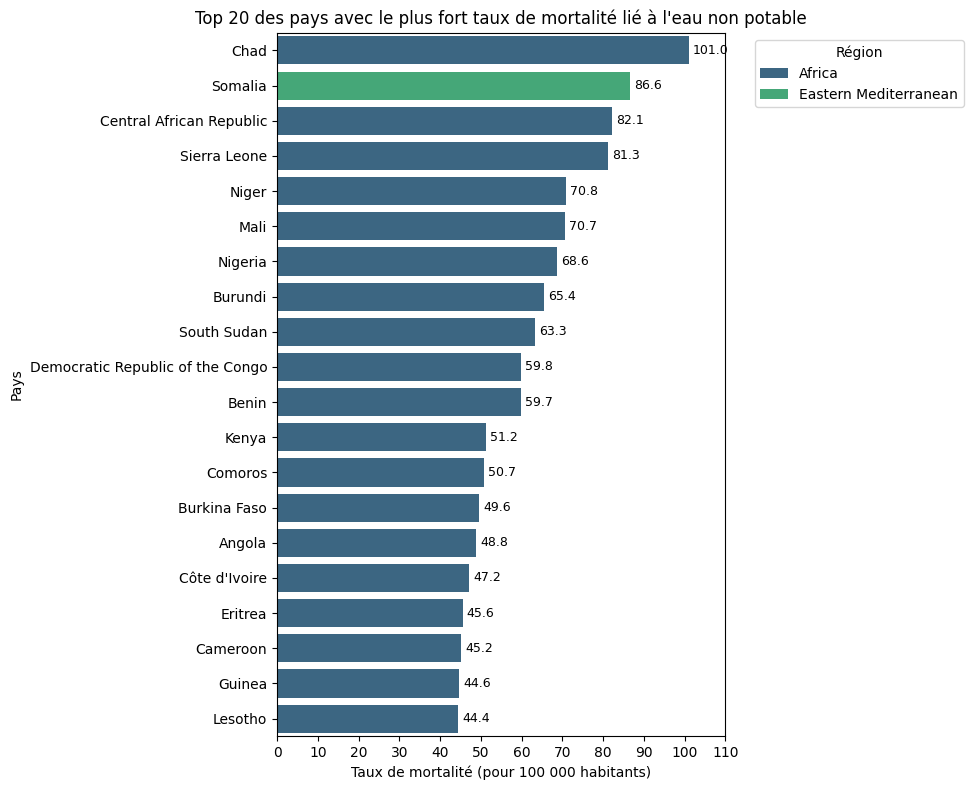

,Country,Region,mortality_rate,basic_water_access_pct
128,Chad,Africa,101.04312,38.70060
71,Somalia,Eastern Mediterranean,86.57523,52.43619
0,Central African Republic,Africa,82.11312,46.33376
99,Sierra Leone,Africa,81.29262,60.80699
129,Niger,Africa,70.81496,50.27306
11,Mali,Africa,70.72140,78.26083
130,Nigeria,Africa,68.62818,71.37663
84,Burundi,Africa,65.40117,60.83055
68,South Sudan,Africa,63.28665,40.67601
101,Democratic Republic of the Congo,Africa,59.75592,43.24332


In [21]:
# Je trie et garde les 20 pays avec le plus fort taux de mortalité
top20_mortality = df_priorite.sort_values('mortality_rate', ascending=False).head(20)

# Je visualise en barplot horizontal pour avoir une viualisation immédiate
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top20_mortality,
    x='mortality_rate',
    y='Country',
    hue='Region',
    dodge=False,
    palette='viridis'
)
plt.title("Top 20 des pays avec le plus fort taux de mortalité lié à l'eau non potable")
plt.xlabel("Taux de mortalité (pour 100 000 habitants)")
plt.ylabel("Pays")
plt.legend(title='Région', bbox_to_anchor=(1.05, 1), loc='upper left')

# J'affiche la valeur exacte à la fin de chaque barre
for i, valeur in enumerate(top20_mortality['mortality_rate']):
    plt.text(valeur + 1, i, f"{valeur:.1f}", va='center', fontsize=9)

# Je force les graduations X pour lisibilité
plt.xticks(range(0, 120, 10))

plt.tight_layout()
plt.show()

# J'affiche le top 20 en tableau
top20_mortality[['Country', 'Region', 'mortality_rate', 'basic_water_access_pct']]

### Interprétation — Top 20 mortalité

→ **19 pays sur 20 sont en Afrique** — concentration géographique marquée  
→ **1 seul pays hors Afrique** : Somalia (Eastern Mediterranean)  
→ **Podium** : Tchad (101.0), Somalia (86.6), Centrafrique (82.1)  
→ **Cas atypique** : le Mali affiche 78% d'accès à l'eau mais 70.7 de mortalité → l'accès seul ne suffit pas, la **qualité** de l'eau compte aussi  
→ Cette visualisation confirme que l'intervention de l'ONG doit se concentrer en **Afrique subsaharienne**, avec une attention particulière à la **qualité** et pas seulement à l'accès

### Question 2 : Le taux de mortalité par région

**Objectif** : au-delà du classement pays par pays, identifier les régions OMS les plus touchées pour orienter la stratégie globale de l'ONG à l'échelle continentale.

**Démarche** : je calcule la moyenne et la médiane du taux de mortalité par région. La médiane complète la moyenne car elle est moins sensible aux valeurs extrêmes (un pays très touché peut tirer la moyenne vers le haut).

                        mean  median  count
Region                                     
Africa                 38.92   38.57     47
Eastern Mediterranean   9.23    1.02     21
South-East Asia         8.21    7.06     11
Western Pacific         4.33    1.71     20
Americas                2.08    1.03     33
Europe                  0.34    0.17     49


<Figure size 1000x600 with 0 Axes>

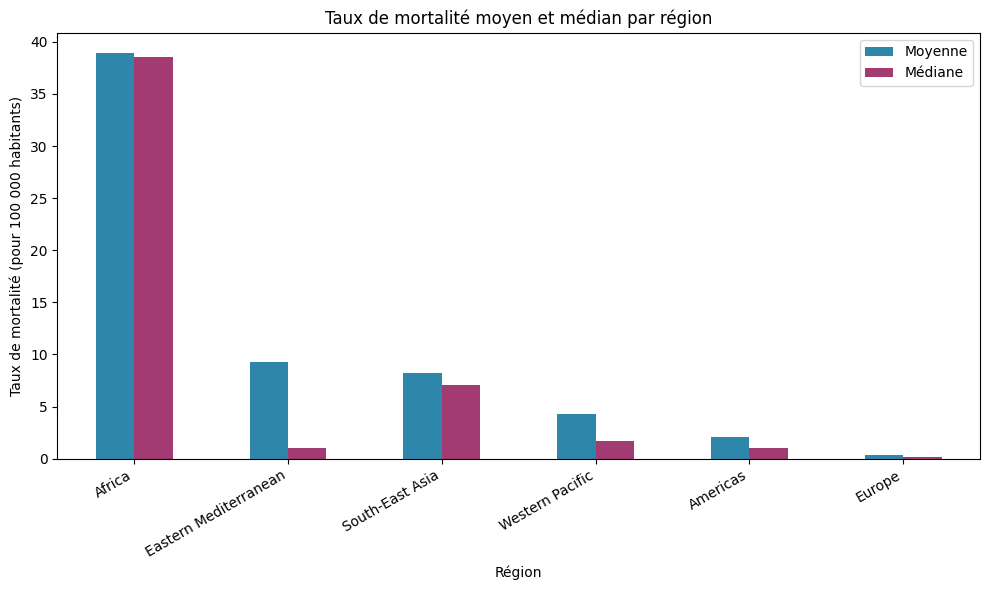

In [22]:
# Je calcule les stats par région
stats_region = df_priorite.groupby('Region')['mortality_rate'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
stats_region = stats_region.round(2)
print(stats_region)

# Je visualise la moyenne et médiane en barplot
plt.figure(figsize=(10, 6))
stats_region[['mean', 'median']].plot(kind='bar', figsize=(10, 6), color=['#2E86AB', '#A23B72'])
plt.title("Taux de mortalité moyen et médian par région")
plt.xlabel("Région")
plt.ylabel("Taux de mortalité (pour 100 000 habitants)")
plt.xticks(rotation=30, ha='right')
plt.legend(['Moyenne', 'Médiane'])
plt.tight_layout()
plt.show()

### Interprétation — Mortalité par région

→ **L'Afrique se détache très nettement** avec un taux moyen de 38.9 et une médiane de 38.6 — l'écart faible entre moyenne et médiane montre que **la région entière est touchée**, pas juste quelques pays  
→ **Eastern Mediterranean** présente un profil atypique : moyenne 9.2 mais médiane 1.0 → un ou deux pays (Somalia en tête) tirent la moyenne vers le haut, alors que le reste de la région est peu impacté  
→ **South-East Asia** affiche une mortalité modérée mais homogène (8.2 / 7.1)  
→ **Western Pacific, Americas et Europe** sont quasi-épargnées (moyenne < 5)  

### Conséquence pour la stratégie de l'ONG
L'intervention doit être **massive et généralisée en Afrique**, puis **ciblée sur quelques pays** dans les autres régions (logique différente selon le profil régional).

### Question 3 : Lien entre mortalité, instabilité politique et accès à l'eau

**Objectif** : comprendre si les pays où la mortalité est forte sont aussi des pays politiquement instables et/ou avec un faible accès à l'eau. Ces corrélations orienteront la construction du score de priorité et la stratégie d'intervention.

**Démarche** : je calcule la matrice de corrélation entre `mortality_rate`, `Political_Stability` et `basic_water_access_pct`, puis je la visualise en heatmap pour lecture immédiate.

**Affichage** : je n'affiche que le **triangle inférieur** de la matrice. Les corrélations étant symétriques (corr(A,B) = corr(B,A)), afficher les deux triangles serait redondant. Je masque aussi la diagonale (corrélation d'une variable avec elle-même = 1, information inutile).

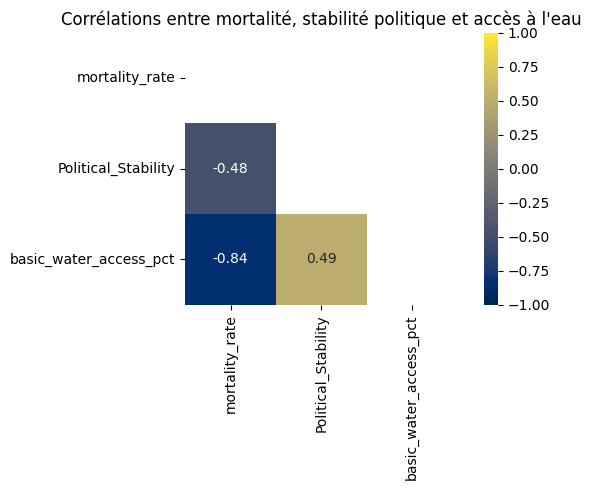

In [27]:
# Je crée un masque pour cacher le triangle supérieur et la diagonale
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Je visualise en heatmap avec le masque
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='cividis', center=0, fmt='.2f', vmin=-1, vmax=1, square=True)
plt.title("Corrélations entre mortalité, stabilité politique et accès à l'eau")
plt.tight_layout()
plt.show()

### Interprétation — Corrélations

→ **Mortalité ↔ Accès à l'eau : -0.84** → corrélation négative **très forte**. Moins un pays a accès à l'eau potable, plus la mortalité est élevée. C'est la relation la plus nette des trois.  

→ **Mortalité ↔ Stabilité politique : -0.48** → corrélation négative **modérée**. Les pays politiquement instables tendent à avoir plus de mortalité, mais le lien est moins direct que celui avec l'accès à l'eau.  

→ **Accès à l'eau ↔ Stabilité politique : +0.49** → corrélation positive **modérée**. Les pays stables ont tendance à avoir un meilleur accès à l'eau, probablement parce qu'un État stable peut investir dans les infrastructures.  

### Conséquences pour la stratégie de l'ONG

→ **L'accès à l'eau est le levier direct** pour réduire la mortalité → cohérent avec la mission de World Vision  
→ **L'instabilité politique est un facteur aggravant**, pas une cause directe → à prendre en compte pour la **faisabilité** des interventions  
→ Dans mon score de priorité, je donnerai un **poids plus fort à l'accès à l'eau et à la mortalité**, et un poids modéré à la stabilité politique (critère de faisabilité)

### Question 4 : Y a-t-il une différence dans l'accès à l'eau selon que la zone est urbaine ou rurale ?

**Objectif** : identifier si les inégalités urbain/rural sont significatives. Cela orienterait l'ONG vers des interventions ciblées sur les zones rurales si l'écart est important.

**Démarche** : je reprends le dataset `df_basicsafewater` d'origine (non filtré sur Total) pour exploiter les granularités Urban et Rural. Je travaille sur 2017 (dernière année) et je compare les distributions par région.Je filtre uniquement sur les 181 pays de 'df_priorite' pour la coherence de mon analyse.

**Choix du boxplot** : je visualise avec un boxplot plutôt qu'un barplot car il permet de voir **la dispersion** à l'intérieur de chaque région (médiane, quartiles, outliers) — une région peut avoir une moyenne correcte tout en cachant des pays très en retard.

Nombre de pays dans l'analyse : 159


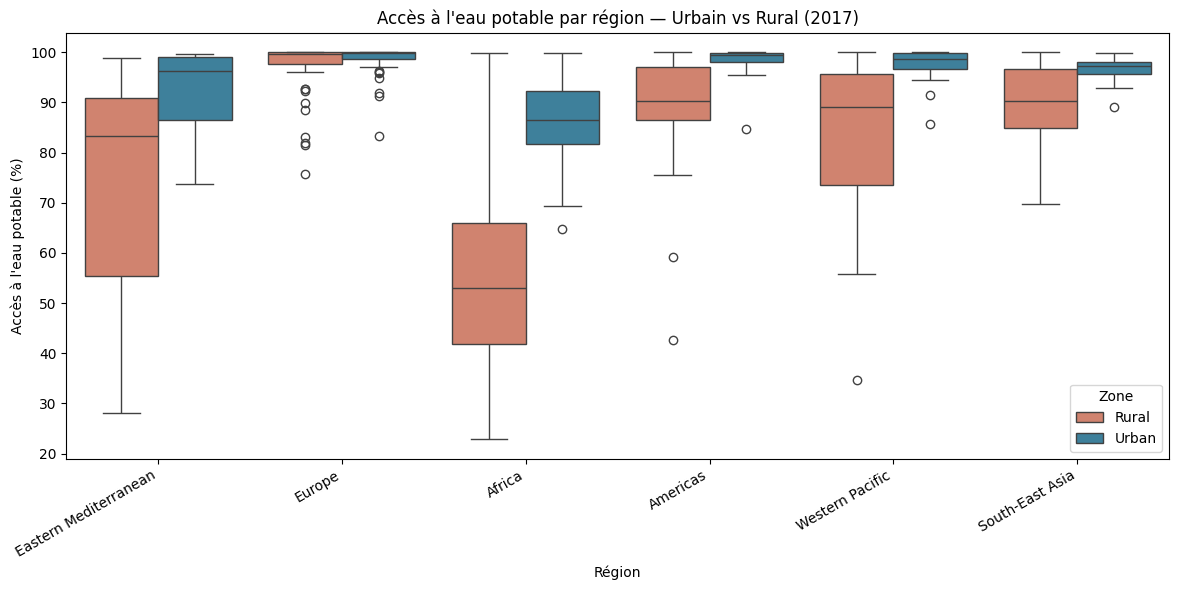

Granularity            Rural  Urban  Ecart_Urbain_Rural
Region                                                 
Africa                  54.3   85.7                31.4
Americas                88.4   98.3                 9.9
Eastern Mediterranean   74.2   92.5                18.3
Europe                  97.0   98.6                 1.6
South-East Asia         89.1   96.3                 7.2
Western Pacific         81.8   97.2                15.4


In [25]:
# Je récupère la liste des 181 pays de df_priorite
pays_retenus = df_priorite['Country'].unique()

# Je filtre sur 2017, Urban/Rural, et uniquement les pays retenus
water_2017 = df_basicsafewater[
    (df_basicsafewater['Year'] == 2017) &
    (df_basicsafewater['Granularity'].isin(['Urban', 'Rural'])) &
    (df_basicsafewater['Country'].isin(pays_retenus))
].copy()

# J'ajoute la région
water_2017 = water_2017.merge(df_region_country, on='Country', how='inner')

# Je supprime les NaN
water_2017 = water_2017.dropna(subset=['basic_water_access_pct'])

print("Nombre de pays dans l'analyse :", water_2017['Country'].nunique())

# Je visualise avec un boxplot par région
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=water_2017,
    x='Region',
    y='basic_water_access_pct',
    hue='Granularity',
    palette={'Urban': '#2E86AB', 'Rural': '#E07A5F'}
)
plt.title("Accès à l'eau potable par région — Urbain vs Rural (2017)")
plt.xlabel("Région")
plt.ylabel("Accès à l'eau potable (%)")
plt.xticks(rotation=30, ha='right')
plt.legend(title='Zone')
plt.tight_layout()
plt.show()

# Je calcule les moyennes pour chiffrer l'écart
moyennes = water_2017.groupby(['Region', 'Granularity'])['basic_water_access_pct'].mean().round(1).unstack()
moyennes['Ecart_Urbain_Rural'] = (moyennes['Urban'] - moyennes['Rural']).round(1)
print(moyennes)

### Interprétation — Urbain vs Rural

**Écarts moyens par région (points de pourcentage)** :

| Région | Rural | Urbain | Écart |
|--------|-------|--------|-------|
| Afrique | 54.3 | 85.7 | **31.4** |
| Eastern Mediterranean | 74.2 | 92.5 | 18.3 |
| Western Pacific | 81.8 | 97.2 | 15.4 |
| Americas | 88.4 | 98.3 | 9.9 |
| South-East Asia | 89.1 | 96.3 | 7.2 |
| Europe | 97.0 | 98.6 | 1.6 |

→ **Écart urbain/rural présent dans toutes les régions**, mais avec des amplitudes très différentes  
→ **Afrique** : écart record de **31.4 points** (54.3% rural vs 85.7% urbain). Les zones rurales descendent jusqu'à 23% d'accès → situation critique  
→ **Eastern Mediterranean** : écart de 18.3 points + forte dispersion (rural de 28% à 99%) → profil très hétérogène, certains pays effondrés  
→ **Western Pacific** : écart de 15.4 points, avec un outlier rural à 34% qui mérite investigation  
→ **Americas, South-East Asia** : écart modéré (7-10 points)  
→ **Europe** : écart minimal (1.6 point) — l'accès est quasi-universel  

### Conséquences pour la stratégie de l'ONG

→ **L'Afrique rurale est la cible n°1** — écart maximal ET niveaux absolus les plus bas  
→ **Eastern Mediterranean** : intervention **ciblée pays par pays** (grande variabilité)  
→ Dans les autres régions, action sur les **poches de pauvreté rurale** (outliers) plutôt que programmes massifs  
→ **Recommandation transverse** : inclure une dimension "zone rurale" dans l'allocation des ressources de l'ONG

### Question 5 : Lien entre taux de mortalité et sexe

**Objectif** : déterminer si hommes ou femmes sont davantage exposés à la mortalité liée à l'eau non potable. Une inégalité significative orienterait l'ONG vers des programmes genrés (ex : hygiène menstruelle, corvée d'eau souvent portée par les femmes).

**Démarche** : j'utilise `df_mortality` d'origine avec les granularités Male et Female, filtré sur mes 181 pays retenus. Je compare les distributions.

**Note sur l'échelle** : je passe en échelle logarithmique (`yscale('log')`) car l'Afrique écrase visuellement les autres régions. L'échelle log permet de comparer les écarts relatifs même quand les ordres de grandeur diffèrent.

Nombre de pays dans l'analyse : 181


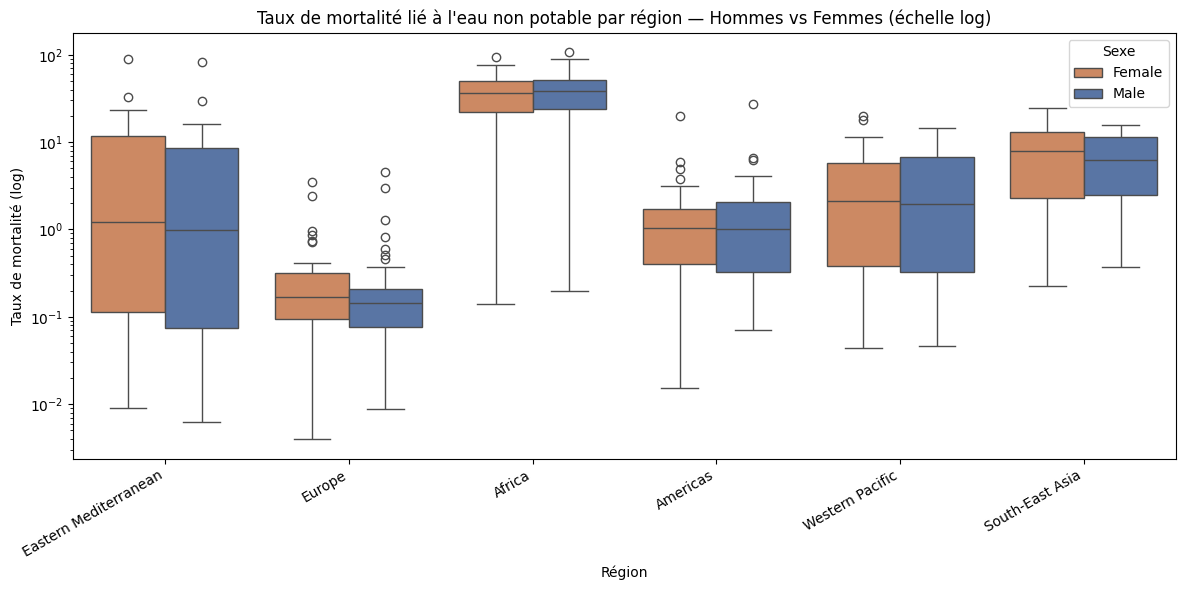

Granularity            Female   Male  Ecart_H_F
Region                                         
Africa                  37.50  40.35       2.85
Americas                 1.90   2.27       0.37
Eastern Mediterranean    9.86   8.60      -1.26
Europe                   0.34   0.34       0.00
South-East Asia          9.10   7.32      -1.78
Western Pacific          4.40   4.26      -0.14


In [29]:
# Je filtre sur les 181 pays retenus et granularités Male/Female
pays_retenus = df_priorite['Country'].unique()

mortality_sex = df_mortality[
    (df_mortality['Granularity'].isin(['Male', 'Female'])) &
    (df_mortality['Country'].isin(pays_retenus))
].copy()

# J'ajoute la région
mortality_sex = mortality_sex.merge(df_region_country, on='Country', how='inner')

print("Nombre de pays dans l'analyse :", mortality_sex['Country'].nunique())

# Je compare en boxplot par région
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=mortality_sex,
    x='Region',
    y='mortality_rate',
    hue='Granularity',
    palette={'Male': '#4C72B0', 'Female': '#DD8452'}
)
plt.yscale('log')
plt.title("Taux de mortalité lié à l'eau non potable par région — Hommes vs Femmes (échelle log)")
plt.xlabel("Région")
plt.ylabel("Taux de mortalité (log)")
plt.xticks(rotation=30, ha='right')
plt.legend(title='Sexe')
plt.tight_layout()
plt.show()

# Je calcule les moyennes
moyennes_sex = mortality_sex.groupby(['Region', 'Granularity'])['mortality_rate'].mean().round(2).unstack()
moyennes_sex['Ecart_H_F'] = (moyennes_sex['Male'] - moyennes_sex['Female']).round(2)
print(moyennes_sex)

### Interprétation — Lien entre mortalité et sexe

**Écarts moyens par région (points, Male - Female)** :

| Région | Female | Male | Écart H-F |
|--------|--------|------|-----------|
| Afrique | 37.50 | 40.35 | **+2.85** |
| Americas | 1.90 | 2.27 | +0.37 |
| Eastern Mediterranean | 9.86 | 8.60 | -1.26 |
| Europe | 0.34 | 0.34 | 0.00 |
| South-East Asia | 9.10 | 7.32 | -1.78 |
| Western Pacific | 4.40 | 4.26 | -0.14 |

→ **Les écarts H/F sont faibles partout** — aucun écart ne dépasse 3 points  
→ **Afrique** : les hommes sont légèrement plus touchés (+2.85) — à rapprocher peut-être des activités masculines en zones à risque (agriculture, travaux d'eau)  
→ **South-East Asia et Eastern Mediterranean** : les femmes sont légèrement plus touchées (-1.78 et -1.26) — hypothèse : corvée d'eau traditionnellement féminine, exposition plus longue  
→ **Europe** : écart nul — universalité de l'accès à l'eau neutralise le genre  

### Conclusion sur la question du sexe

→ **Le taux de mortalité lié à l'eau n'est pas fortement lié au sexe** : les écarts observés sont faibles et varient selon les régions  
→ **Ce critère ne sera pas intégré au score de priorité** : il n'a pas de pouvoir discriminant entre pays  
→→ **En revanche, il reste pertinent pour les prochaines campagnes ciblées** : les régions où les femmes sont plus touchées (Asie du Sud-Est) pourraient bénéficier d'actions spécifiques (ex : sécurisation de la corvée d'eau).

### Question 6: Évolution de l'accès à l'eau par région (2000-2017)

**Objectif** : au-delà du classement actuel, je me pose la question suivante: l'accès à l'eau **progresse ou stagne** t-elle dans chaque région? Cette analyse permet de valoriser les efforts déjà consentis et d'identifier les régions où la situation ne s'améliore pas malgré les interventions passées.

**Démarche** : j'utilise `df_temporel` pour calculer la moyenne annuelle d'accès à l'eau par région, puis je visualise l'évolution sur 17 ans.

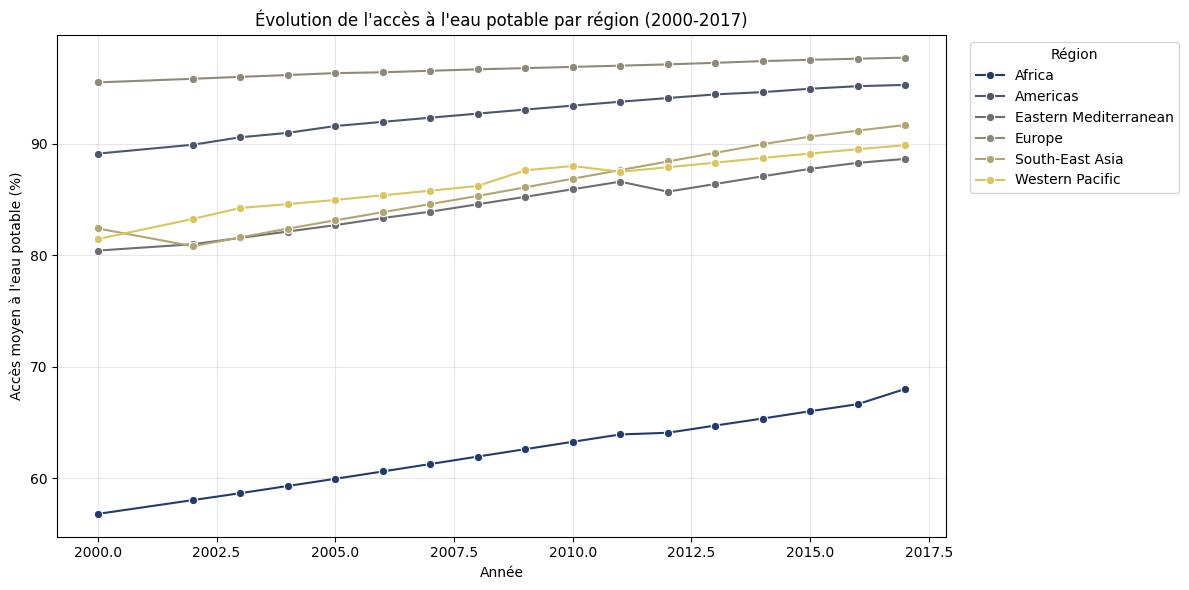

Year                        2000       2017  Progression_2000_2017
Region                                                            
Africa                 56.779803  67.989872                   11.2
South-East Asia        82.385922  91.664895                    9.3
Western Pacific        81.434235  89.850117                    8.4
Eastern Mediterranean  80.401285  88.623356                    8.2
Americas               89.096840  95.262616                    6.2
Europe                 95.487011  97.706816                    2.2


In [30]:
# Je calcule la moyenne d'accès à l'eau par région et par année
evolution = df_temporel.groupby(['Year', 'Region'])['basic_water_access_pct'].mean().reset_index()

# Je visualise en courbes
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=evolution,
    x='Year',
    y='basic_water_access_pct',
    hue='Region',
    marker='o',
    palette='cividis'
)
plt.title("Évolution de l'accès à l'eau potable par région (2000-2017)")
plt.xlabel("Année")
plt.ylabel("Accès moyen à l'eau potable (%)")
plt.legend(title='Région', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Je calcule la progression absolue entre 2000 et 2017 par région
progression = df_temporel.groupby(['Region', 'Year'])['basic_water_access_pct'].mean().unstack()
progression['Progression_2000_2017'] = (progression[2017] - progression[2000]).round(1)
print(progression[[2000, 2017, 'Progression_2000_2017']].sort_values('Progression_2000_2017', ascending=False))

### Interprétation — Évolution de l'accès à l'eau (2000-2017)

**Progression par région (points de pourcentage sur 17 ans)** :

| Région | 2000 | 2017 | Progression |
|--------|------|------|-------------|
| Afrique | 56.8 | 68.0 | **+11.2** |
| South-East Asia | 82.4 | 91.7 | +9.3 |
| Western Pacific | 81.4 | 89.9 | +8.4 |
| Eastern Mediterranean | 80.4 | 88.6 | +8.2 |
| Americas | 89.1 | 95.3 | +6.2 |
| Europe | 95.5 | 97.7 | +2.2 |

→ **Toutes les régions progressent** — aucune régression observée sur 17 ans  
→ **Afrique** : plus forte progression (+11.2 points) mais **part d'un niveau très bas** (56.8%). En 2017, encore à 68% → rattrapage en cours mais lent  
→ **South-East Asia** : belle progression (+9.3 points), passe de 82% à 92% → objectif universel en vue  
→ **Eastern Mediterranean** : progression régulière mais un **décrochage visible vers 2011-2012** → à relier à des crises régionales (Syrie, Yémen)  
→ **Europe** : progression faible (+2.2) car **déjà proche de 100%** — effet plafond  

### Conséquences pour la stratégie de l'ONG

→ **L'Afrique progresse mais reste très en retard** : au rythme actuel (+0.66 pt/an), il faudrait ~50 ans pour atteindre 100%  
→ **Argument fort pour les investisseurs** : l'aide passée fonctionne (progression mesurable), mais doit être **accélérée** pour l'Afrique  
→ **Eastern Mediterranean** : surveiller les effets des conflits régionaux sur l'accès à l'eau

### Question 7 : Où puis-je sauver le plus de vies en valeur absolue ?

**Objectif** : je complète l'analyse par taux de mortalité avec une vision en **volume absolu**. Un pays à faible taux mais très peuplé peut représenter plus de décès qu'un pays à fort taux mais peu peuplé. Je veux identifier les pays où mon intervention aurait le plus d'impact en vies sauvées.

**Démarche** : j'utilise la colonne `WASH deaths` de `df_mortality` qui donne le nombre absolu de décès. Je trie pour identifier les pays avec le plus grand volume de décès.

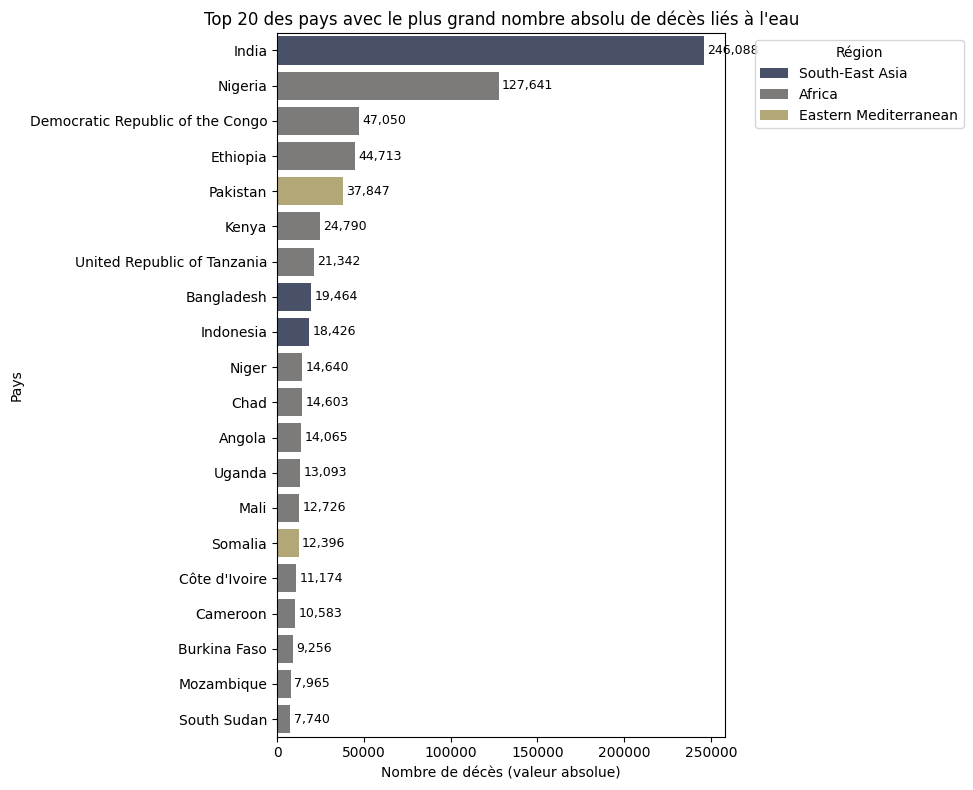

,Country,Region,WASH deaths,mortality_rate,Population
151,India,South-East Asia,246087.900,18.58389,1338676.785
130,Nigeria,Africa,127641.300,68.62818,190873.244
101,Democratic Republic of the Congo,Africa,47049.520,59.75592,81398.764
51,Ethiopia,Africa,44713.330,43.66399,106399.924
148,Pakistan,Eastern Mediterranean,37847.050,19.58922,207906.209
83,Kenya,Africa,24790.320,51.15460,50221.142
94,United Republic of Tanzania,Africa,21341.520,38.40323,54660.339
88,Bangladesh,South-East Asia,19464.030,11.94467,159685.424
158,Indonesia,South-East Asia,18426.380,7.05721,264650.963
129,Niger,Africa,14639.560,70.81496,21602.382


In [31]:
# Je trie mes pays par nombre absolu de décès (WASH deaths)
top20_deaths = df_priorite.sort_values('WASH deaths', ascending=False).head(20)

# Je visualise en barplot horizontal
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top20_deaths,
    x='WASH deaths',
    y='Country',
    hue='Region',
    dodge=False,
    palette='cividis'
)

# J'affiche les valeurs à la fin de chaque barre
for i, valeur in enumerate(top20_deaths['WASH deaths']):
    plt.text(valeur + 2000, i, f"{valeur:,.0f}", va='center', fontsize=9)

plt.title("Top 20 des pays avec le plus grand nombre absolu de décès liés à l'eau")
plt.xlabel("Nombre de décès (valeur absolue)")
plt.ylabel("Pays")
plt.legend(title='Région', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# J'affiche le tableau détaillé
top20_deaths[['Country', 'Region', 'WASH deaths', 'mortality_rate', 'Population']]

### Interprétation — Top 20 décès absolus

→ **Inde en tête avec 246 088 décès** — alors que son taux de mortalité (non affiché dans le top 20 précédent) est pourtant modéré. Sa population massive (~1.3 milliard) en fait le pays avec le plus grand volume de victimes  
→ **Nigeria en 2e position (127 641 décès)** — combine taux élevé ET forte population, double facteur aggravant  
→ **3 régions apparaissent** : Afrique, South-East Asia, Eastern Mediterranean. L'Afrique reste dominante mais l'Asie entre dans le classement (Inde, Bangladesh, Indonésie, Pakistan)  
→ **Comparaison avec le top 20 mortalité** : le Tchad (1er en taux, 101/100 000) tombe à la 11e place en volume absolu (14 603 décès) car sa population est limitée  

### Deux logiques d'intervention complémentaires

| Critère | Pays cibles | Logique |
|---------|-------------|---------|
| **Taux de mortalité** | Tchad, Somalia, Centrafrique | Urgence humanitaire ciblée |
| **Volume absolu** | Inde, Nigeria, RDC, Éthiopie | Impact maximal en vies sauvées |

### Conséquences pour la stratégie de l'ONG

→ **Je dois intégrer la population dans mon score** pour ne pas sous-estimer les pays très peuplés  
→ Le **Nigeria apparaît dans les 2 tops** (taux ET volume) → pays doublement prioritaire  
→ L'**Inde** mérite une intervention massive malgré un taux modéré car le volume de vies est énorme  
→ L'ONG doit **arbitrer entre deux logiques** : urgence (taux) vs impact (volume), ou combiner les deux dans le score de priorité

## Synthèse de la Phase 2 — Ce que j'ai appris

### Principaux constats

→ **Concentration géographique massive en Afrique** : 19 des 20 pays les plus touchés y sont, avec un taux de mortalité moyen de 38.9 contre 0.3 en Europe — soit un rapport de plus de 100  

→ **L'accès à l'eau est le facteur déterminant** : corrélation de -0.84 avec la mortalité. Plus qu'un simple lien, c'est quasiment une relation de cause à effet  

→ **La stabilité politique est un facteur secondaire** : corrélation de -0.48 avec la mortalité. Elle joue, mais moins directement. Je la retiendrai comme critère de **faisabilité** plutôt que d'urgence  

→ **Les inégalités urbain/rural sont criantes en Afrique** : 31.4 points d'écart (54.3% rural vs 85.7% urbain). Les zones rurales africaines sont la cible prioritaire absolue  

→ **Le sexe n'a pas d'impact majeur** sur la mortalité : écarts inférieurs à 3 points partout. Ce critère ne sera pas intégré au score  

→ **La situation s'améliore partout, mais trop lentement en Afrique** : progression de +11.2 points en 17 ans, mais au rythme actuel il faudrait encore 50 ans pour atteindre l'accès universel  

→ **Deux logiques d'intervention coexistent** : l'urgence (taux de mortalité → Tchad, Somalia) et l'impact maximal (volume absolu → Inde, Nigeria, RDC)  

### Variables à retenir pour le score de priorité

| Variable | Rôle | Logique |
|----------|------|---------|
| Taux de mortalité | Variable cible principale | Urgence sanitaire |
| Accès à l'eau (inversé) | Variable explicative forte | Besoin en infrastructure |
| Population | Facteur d'impact | Maximiser les vies sauvées |
| Stabilité politique | Facteur de faisabilité | Capacité d'intervention |

### Variable écartée

→ **Sexe** : pas assez discriminant entre pays pour hiérarchiser les interventions. Reste pertinent pour concevoir des campagnes ciblées mais pas pour le score.

### Direction pour la suite

Je construis maintenant un **score composite** qui combinera ces 4 variables avec des pondérations justifiées par les corrélations observées. L'accès à l'eau et la mortalité, les deux facteurs les plus corrélés, recevront les poids les plus forts.

## Phase 3 — Score de priorité d'intervention

### Objectif
Je construis un **indicateur unique** qui hiérarchise les 181 pays selon leur besoin d'intervention pour l'ONG World Vision. Ce score synthétise 4 dimensions complémentaires en un classement opérationnel que les investisseurs peuvent comprendre immédiatement.

### Pourquoi un score composite
→ Aucune variable seule ne suffit : un pays à forte mortalité peut être inaccessible politiquement, un pays peu peuplé peut avoir un impact limité même avec un fort taux  
→ Le score combine **urgence + besoin + impact + faisabilité** en une note unique  
→ Cela me permet de passer d'une analyse descriptive à une **recommandation chiffrée et actionnable**

### Variables retenues et justification

| Variable | Rôle | Sens | Poids |
|----------|------|------|-------|
| `mortality_rate` | Urgence sanitaire | Plus c'est haut = plus prioritaire | 35% |
| `basic_water_access_pct` (inversé) | Besoin en infrastructure | Moins l'accès est bon = plus prioritaire | 30% |
| `Population` | Impact potentiel | Plus de monde = plus de vies à sauver | 20% |
| `Political_Stability` | Faisabilité | Plus c'est stable = intervention plus sûre | 15% |

### Justification des pondérations
→ **Mortalité (35%)** : variable cible de la mission de l'ONG, donc poids dominant  
→ **Accès à l'eau (30%)** : levier d'action direct, fortement corrélé à la mortalité (-0.84)  
→ **Population (20%)** : intègre la logique d'impact absolu mise en évidence question 7  
→ **Stabilité politique (15%)** : critère de faisabilité, plus faible car un pays instable reste éligible si le besoin est critique  

### Méthode
1. Je normalise chaque variable entre 0 et 1 (Min-Max scaling) pour que les échelles soient comparables  
2. J'inverse les variables "à maximiser" (accès à l'eau, stabilité politique) pour que **haut = prioritaire** partout  
3. Je calcule la moyenne pondérée  
4. Je classe les pays du plus prioritaire au moins prioritaire

In [ ]:
# Je crée une copie pour travailler le score
df_score = df_priorite.copy()

# Je normalise chaque variable entre 0 et 1 (Min-Max)
for col in ['mortality_rate', 'basic_water_access_pct', 'Population', 'Political_Stability']:
    min_val = df_score[col].min()
    max_val = df_score[col].max()
    df_score[col + '_norm'] = (df_score[col] - min_val) / (max_val - min_val)

# Je vérifie que toutes les normalisations sont bien entre 0 et 1
print(df_score[[c for c in df_score.columns if '_norm' in c]].describe()) 

       mortality_rate_norm  basic_water_access_pct_norm  Population_norm  \
count           181.000000                   181.000000       181.000000   
mean              0.124913                     0.786314         0.025022   
std               0.206804                     0.270824         0.080794   
min               0.000000                     0.000000         0.000000   
25%               0.001945                     0.649436         0.002054   
50%               0.013365                     0.925362         0.007016   
75%               0.181230                     0.990250         0.021684   
max               1.000000                     1.000000         1.000000   

       Political_Stability_norm  
count                181.000000  
mean                   0.615113  
std                    0.213523  
min                    0.000000  
25%                    0.493421  
50%                    0.633772  
75%                    0.787281  
max                    1.000000  


## Vérification de la normalisation
→ Toutes les variables vont bien de 0 à 1.
→ mortality_rate_norm : médiane 0.013 → la majorité des pays ont un taux faible, la distribution est tirée par quelques cas extrêmes (Tchad, Somalia)
→ basic_water_access_pct_norm : médiane 0.93 → la plupart des pays ont un bon accès, les outliers sont ceux en dessous
→ Population_norm : médiane 0.007 → très asymétrique (Inde et Chine écrasent tout)
→ Political_Stability_norm : médiane 0.63 → distribution plus équilibrée

### Étape 2 : Inversion d'une variable "à maximiser"

**Logique** : dans mon score, je veux que **"haut = prioritaire"** partout. Une variable a une logique inversée :
- **Accès à l'eau** : un pays avec **peu d'accès** est prioritaire → j'inverse

**La stabilité politique n'est PAS inversée** : un pays politiquement instable rend l'intervention plus complexe et risquée. Je considère la stabilité comme un **critère de faisabilité** : plus un pays est stable, mieux l'ONG peut y intervenir efficacement. Un score élevé sur cette variable signifie donc "intervention réalisable".

**Formule d'inversion** : `1 - valeur_normalisée`

In [36]:
# J'inverse uniquement l'accès à l'eau
df_score['basic_water_access_pct_norm_inv'] = 1 - df_score['basic_water_access_pct_norm']

# Je vérifie sur quelques pays clés
print(df_score[['Country', 'basic_water_access_pct', 'basic_water_access_pct_norm_inv',
                'Political_Stability', 'Political_Stability_norm']].head(5))

                    Country  basic_water_access_pct  \
0  Central African Republic                46.33376   
1                 Argentina                99.07838   
2                   Eritrea                51.84972   
3                   Liberia                72.94803   
4                 Lithuania                97.54207   

   basic_water_access_pct_norm_inv  Political_Stability  \
0                         0.875477                -1.79   
1                         0.015035                 0.20   
2                         0.785494                -0.66   
3                         0.441309                -0.36   
4                         0.040097                 0.78   

   Political_Stability_norm  
0                  0.252193  
1                  0.688596  
2                  0.500000  
3                  0.565789  
4                  0.815789  


### Vérification rapide
→ RCA : politique -1.79 → norm 0.25 (faible faisabilité) → pénalisera le score
→ Lituanie : politique 0.78 → norm 0.82 (haute faisabilité) → boostera le score si besoin
→ Argentine : politique 0.20 → norm 0.69 (bonne faisabilité)

-> ***Cohérent avec mes décisions prise en amont***

### Étape 3 : Calcul du score de priorité pondéré

**Formule** :
Score = 0.35 × mortalité_norm + 0.30 × (1 - accès_eau_norm) + 0.20 × population_norm + 0.15 × stabilité_politique_norm

Le score obtenu est compris entre 0 et 1, où **1 = priorité maximale**.

In [37]:
# Je calcule le score pondéré selon mes 4 critères
df_score['priority_score'] = (
    0.35 * df_score['mortality_rate_norm'] +
    0.30 * df_score['basic_water_access_pct_norm_inv'] +
    0.20 * df_score['Population_norm'] +
    0.15 * df_score['Political_Stability_norm']
)

# Je trie les pays par score décroissant
df_score = df_score.sort_values('priority_score', ascending=False).reset_index(drop=True)

# J'affiche le top 20 des pays prioritaires
top20_priorite = df_score.head(20)[['Country', 'Region', 'priority_score', 'mortality_rate',
                                     'basic_water_access_pct', 'Population', 'Political_Stability']]
print(top20_priorite.to_string())

                             Country                 Region  priority_score  mortality_rate  basic_water_access_pct  Population  Political_Stability
0                               Chad                 Africa        0.706506       101.04312                38.70060   15016.753                -1.29
1           Central African Republic                 Africa        0.585561        82.11312                46.33376    4537.686                -1.79
2                       Sierra Leone                 Africa        0.569893        81.29262                60.80699    7488.423                -0.04
3                            Somalia  Eastern Mediterranean        0.557194        86.57523                52.43619   14589.179                -2.26
4                              Niger                 Africa        0.546799        70.81496                50.27306   21602.382                -1.27
5                        South Sudan                 Africa        0.527275        63.28665               

### Visualisation du classement des 20 pays prioritaires

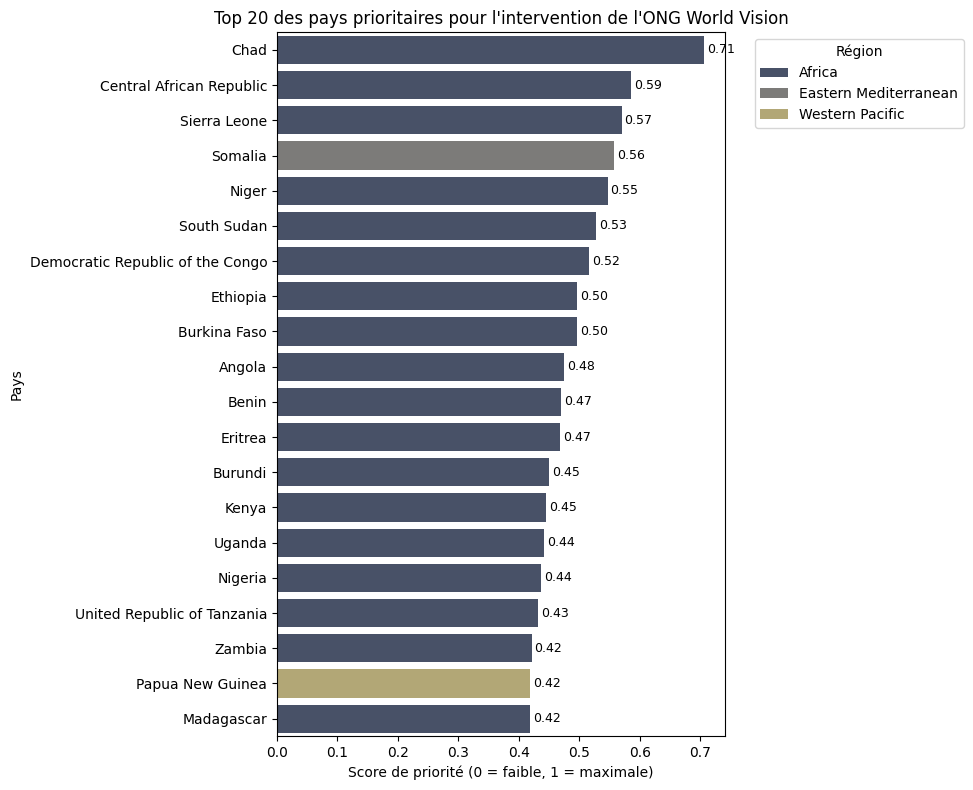

In [38]:
# Je visualise le top 20 des pays selon le score de priorité
top20_score = df_score.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top20_score,
    x='priority_score',
    y='Country',
    hue='Region',
    dodge=False,
    palette='cividis'
)

# J'affiche la valeur du score à la fin de chaque barre
for i, valeur in enumerate(top20_score['priority_score']):
    plt.text(valeur + 0.005, i, f"{valeur:.2f}", va='center', fontsize=9)

plt.title("Top 20 des pays prioritaires pour l'intervention de l'ONG World Vision")
plt.xlabel("Score de priorité (0 = faible, 1 = maximale)")
plt.ylabel("Pays")
plt.legend(title='Région', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Export du dataset de score pour Power BI

In [39]:
# J'exporte df_score qui contient le classement complet pour le dashboard
df_score.to_parquet('../data/df_score.parquet', index=False)
print(f"Export terminé : df_score — {df_score.shape[0]} lignes × {df_score.shape[1]} colonnes")

Export terminé : df_score — 181 lignes × 15 colonnes


### Interprétation — Top 20 des pays prioritaires

**Le Tchad arrive en tête avec un score de 0.71**, cumulant un taux de mortalité record (101), le plus faible accès à l'eau du monde (38.7%) et une population significative (15 M). Son instabilité politique (-1.29) **limite cependant la faisabilité** de l'intervention et a pesé à la baisse dans le score via le critère de faisabilité.

**Podium complet** :
→ **Tchad** (0.71) — urgence sanitaire maximale, mais intervention complexe politiquement  
→ **Centrafrique** (0.59) — mortalité très élevée, mais pays le plus instable du top (-1.79) → faisabilité très faible  
→ **Sierra Leone** (0.57) — mortalité forte **et** stabilité politique correcte (-0.04) → **profil idéal pour l'ONG** : besoin réel + intervention réalisable  

### Arbitrages besoin / faisabilité

Le score met en évidence deux profils de pays dans le top 20 :

**Profil "urgence complexe"** — fort besoin mais instabilité forte  
→ Tchad, Centrafrique, Somalia, Soudan du Sud, RDC, Burundi  
→ Interventions possibles mais nécessitent des partenariats locaux solides et des garanties sécuritaires  

**Profil "intervention optimale"** — besoin réel et stabilité correcte  
→ Sierra Leone, Bénin, Zambie, Madagascar  
→ L'ONG peut y déployer des programmes efficaces rapidement  

### Ce que révèle ce classement

→ **19 pays sur 20 sont en Afrique** — cohérent avec les analyses précédentes  
→ **Somalia** est le seul pays hors Afrique dans le top 20  
→ **Des pays très peuplés émergent** grâce au critère population : Éthiopie (106 M), RDC (81 M), Nigeria (190 M) — impact absolu majeur en vies potentiellement sauvées  
→ **Des pays moins peuplés mais en détresse extrême** apparaissent aussi : Sierra Leone, Burundi, Erythrée — besoin par habitant maximal  
→ Les scores sont **très contrastés** : de 0.71 pour le Tchad à moins de 0.05 pour l'Europe → le score discrimine fortement les priorités  

### Conclusion de la Phase 3

Ce score composite transforme mon analyse descriptive en **recommandation opérationnelle chiffrée**. Il permet à l'ONG World Vision de :
→ **Justifier ses choix d'intervention** auprès des investisseurs avec un argument data-driven  
→ **Prioriser ses efforts** en combinant urgence (mortalité, accès), impact (population) et faisabilité (stabilité politique)  
→ **Différencier les stratégies** selon les deux profils de pays identifiés : interventions lourdes dans les pays stables, partenariats sécurisés dans les pays instables  
→ **Sortir du modèle artisanal** pour adopter une approche rigoureuse, reproductible et actualisable chaque année

## Conclusion globale

### Démarche réalisée

J'ai construit une analyse complète permettant à l'ONG World Vision de passer d'une approche artisanale à une **stratégie d'intervention data-driven**. Mon travail s'articule en trois grandes étapes :

1. **Consolidation** : j'ai croisé 5 jeux de données (population, accès à l'eau, mortalité, stabilité politique, régions) pour obtenir deux datasets exploitables — un snapshot pour le classement, un historique pour les tendances  

2. **Analyse exploratoire** : j'ai répondu à 7 questions métier qui ont révélé une **concentration massive des besoins en Afrique subsaharienne**, une corrélation très forte entre accès à l'eau et mortalité (-0.84), et des inégalités urbain/rural majeures dans les pays les plus touchés  

3. **Score de priorité** : j'ai synthétisé 4 critères (urgence sanitaire, besoin en infrastructure, impact potentiel, faisabilité politique) dans un indicateur composite qui classe les 181 pays selon leur priorité d'intervention  

### Résultats clés

→ **19 des 20 pays prioritaires se situent en Afrique**, avec le Tchad en tête (score 0.71)  
→ **Deux profils d'intervention** se dégagent : pays en urgence complexe (Tchad, RCA, Somalia) et pays à intervention optimale (Sierra Leone, Bénin, Zambie)  
→ **L'accès à l'eau progresse partout**, mais au rythme actuel il faudrait 50 ans à l'Afrique pour atteindre l'accès universel — l'aide doit être **accélérée**  

### Limites de l'analyse

→ Les données de mortalité ne couvrent qu'**une seule année (2016)** — pas d'analyse temporelle possible sur ce critère  
→ La colonne "safely managed drinking-water" a été abandonnée (trop de données manquantes) — je me suis limitée à l'eau "basique"  
→ Les **poids du score** reposent sur une justification métier mais restent un choix d'analyste → je pourrais tester d'autres pondérations  

### Vers le dashboard et les slides

Les datasets consolidés sont exportés au format Parquet. Ils alimentent un dashboard Power BI offrant trois vues (mondiale, régionale, nationale) et une carte interactive. Le tout est synthétisé dans une présentation destinée aux investisseurs pour justifier l'allocation des ressources de l'ONG.